# Лабораторна робота 1 — Дослідження даних з NumPy, Pandas та scikit-learn

**Набір даних:** `kc_house_data.csv`  
**Дозволені бібліотеки:** NumPy, Pandas, Matplotlib, scikit-learn (усі модулі)

## Налаштування — встановлення залежностей та імпорт

Запустіть комірку нижче один раз, щоб переконатись, що всі необхідні пакети встановлені.

In [ ]:
# Встановлення залежностей (можна запускати повторно)
import sys
python -m pip install numpy pandas matplotlib scikit-learn --quiet


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)


---
## Завдання 1 — Розминка з NumPy

**а)** Створіть масив NumPy з 10 000 значень, що підпорядковані нормальному розподілу N(0, 1). Обчисліть середнє, стандартне відхилення, мінімум і максимум за допомогою функцій NumPy — **без Python-циклів**.

**б)** Підрахуйте, скільки значень виходять за межі ±2 стандартних відхилення, використовуючи логічну індексацію. Яка це відсоткова частка? Порівняйте з теоретичним значенням ≈4,55 %.

In [2]:
# Завдання 1а — створіть масив і обчисліть статистику
# ВАШ КОД ТУТ
np.random.seed(42) # Задаємо seed для відтворюваності результатів
data = np.random.randn(10000) # Нормальний розподіл N(0, 1)

mean_val = np.mean(data)
std_val = np.std(data)
min_val = np.min(data)
max_val = np.max(data)

print(f"Середнє: {mean_val:.4f}")
print(f"Стандартне відхилення: {std_val:.4f}")
print(f"Мінімум: {min_val:.4f}")
print(f"Максимум: {max_val:.4f}")

Середнє: -0.0021
Стандартне відхилення: 1.0034
Мінімум: -3.9224
Максимум: 3.9262


In [3]:
# Завдання 1б — підрахуйте викиди за допомогою логічної індексації
# ВАШ КОД ТУТ
# Знаходимо межі ±2 стандартних відхилення від середнього
lower_bound = mean_val - 2 * std_val
upper_bound = mean_val + 2 * std_val

# Використовуємо логічну індексацію для пошуку викидів
outliers = data[(data < lower_bound) | (data > upper_bound)]
percentage = (len(outliers) / len(data)) * 100

print(f"Кількість значень поза межами ±2 відхилень: {len(outliers)}")
print(f"Відсоткова частка: {percentage:.2f}%")

Кількість значень поза межами ±2 відхилень: 462
Відсоткова частка: 4.62%


**Ваша відповідь (б):** *відсоткова частка значень, що виходять за межі ±2 стандартних відхилень, становить 4.62%. Це дуже близько до теоретичного очікування у 4.55% (оскільки за правилом двох сигм близько 95.45% значень нормального розподілу лежать у межах двох стандартних відхилень від середнього).*

---
## Завдання 2 — Завантаження та огляд набору даних

Завантажте `kc_house_data.csv` у Pandas DataFrame та дайте відповідь на питання нижче, написавши код:

1. Скільки рядків і стовпців у наборі даних?
2. Які мінімум, максимум, середнє та медіана цін на будинки?
3. Скільки унікальних поштових індексів є у наборі даних? Який поштовий індекс має найбільше оголошень?

In [4]:
# Завантаження набору даних
sales = pd.read_csv('kc_house_data.csv')
sales.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [5]:
# 2-і) Скільки рядків і стовпців?
# ВАШ КОД ТУТ
rows, cols = sales.shape
print(f"Рядки: {rows}")
print(f"Стовпці: {cols}")

Рядки: 21613
Стовпці: 21


In [6]:
# 2-іі) Мінімум, максимум, середнє та медіана ціни
# ВАШ КОД ТУТ
price_min = sales['price'].min()
price_max = sales['price'].max()
price_mean = sales['price'].mean()
price_median = sales['price'].median()

print(f"Мінімум: {price_min}")
print(f"Максимум: {price_max}")
print(f"Середнє: {price_mean:.2f}")
print(f"Медіана: {price_median}")

Мінімум: 75000.0
Максимум: 7700000.0
Середнє: 540088.14
Медіана: 450000.0


In [7]:
# 2-ііі) Кількість унікальних поштових індексів; індекс з найбільшою кількістю оголошень
# ВАШ КОД ТУТ
unique_zipcodes = sales['zipcode'].nunique()
top_zipcode = sales['zipcode'].value_counts().idxmax()
top_zipcode_count = sales['zipcode'].value_counts().max()

print(f"Кількість унікальних поштових індексів: {unique_zipcodes}")
print(f"Поштовий індекс з найбільшою кількістю оголошень: {top_zipcode} ({top_zipcode_count} оголошень)")

Кількість унікальних поштових індексів: 70
Поштовий індекс з найбільшою кількістю оголошень: 98103 (602 оголошень)


---
## Завдання 3 — Візуалізація даних

Створіть **два графіки поруч**:

- **Лівий:** гістограма `price` (50 інтервалів, логарифмічна шкала по осі X).
- **Правий:** діаграма розсіювання `sqft_living` vs `price`, де кольором точок позначено `bedrooms`. Додайте підписи осей і colorbar.

Одним реченням для кожного графіка опишіть, що ви спостерігаєте.

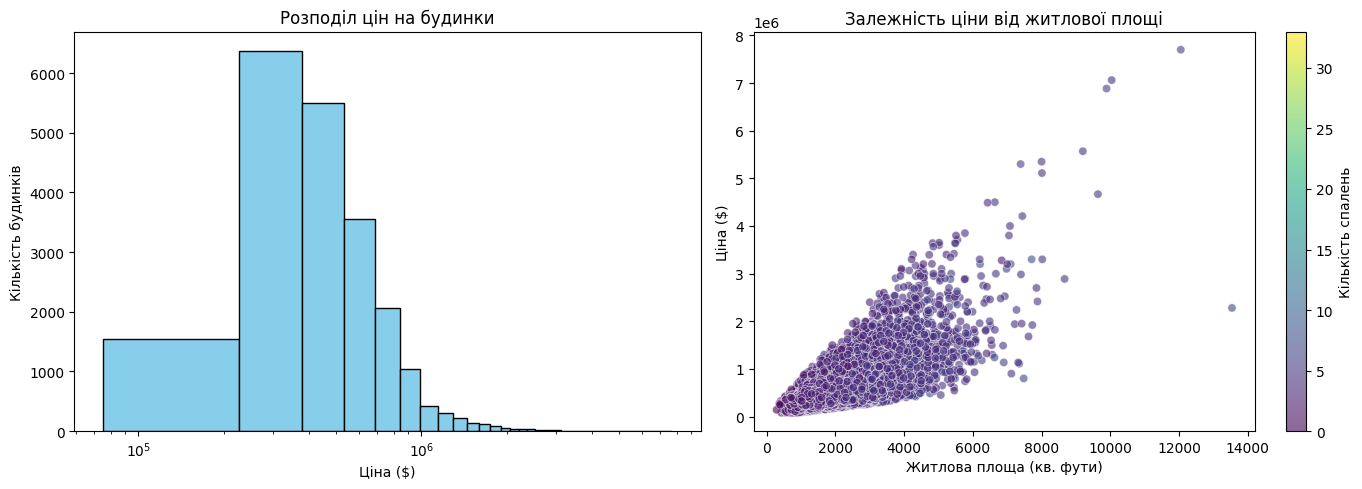

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Завдання 3 — лівий графік: гістограма ціни
# ВАШ КОД ТУТ
axes[0].hist(sales['price'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xscale('log')
axes[0].set_title('Розподіл цін на будинки')
axes[0].set_xlabel('Ціна ($)')
axes[0].set_ylabel('Кількість будинків')

# Завдання 3 — правий графік: діаграма розсіювання sqft_living vs price
# ВАШ КОД ТУТ
sc = axes[1].scatter(sales['sqft_living'], sales['price'], c=sales['bedrooms'], cmap='viridis', alpha=0.6, edgecolors='w', linewidth=0.5)
axes[1].set_title('Залежність ціни від житлової площі')
axes[1].set_xlabel('Житлова площа (кв. фути)')
axes[1].set_ylabel('Ціна ($)')

# Додавання colorbar
cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_label('Кількість спалень')

plt.tight_layout()
plt.show()


**Спостереження (лівий графік):** *Розподіл цін є логнормальним, тому на логарифмічній шкалі він набуває вигляду симетричної дзвоноподібної кривої. Основна маса будинків зосереджена в ціновому діапазоні приблизно від 200 тисяч до 1 мільйона доларів. Водночас на ринку присутня невелика кількість дуже дорогих маєтків, які утворюють довгий хвіст розподілу та зміщують середнє значення вправо.*

**Спостереження (правий графік):** *На діаграмі розсіювання простежується чітка позитивна лінійна кореляція, яка показує, що зі збільшенням житлової площі зростає і загальна ціна будинку. При цьому для будинків малої площі ціни згруповані дуже щільно, але зі збільшенням площі розкид цін суттєво зростає через вплив інших факторів, таких як локація. Кольорова шкала підтверджує очікувану тенденцію: більші за площею будинки зазвичай мають більше спалень.*

---
## Завдання 4 — Навчання та оцінка регресійної моделі

Розбийте дані 80/20 (`random_state=42`). Навчіть `LinearRegression` з scikit-learn для передбачення `price` за єдиною ознакою `sqft_living`.

1. Вкажіть вільний член (intercept) та коефіцієнт для `sqft_living`.
2. Обчисліть MSE і RMSE на тестовій вибірці.
3. Яка передбачувана ціна будинку площею 2 500 кв. футів?

In [9]:
# Поділ на навчальну та тестову вибірки
train_data, test_data = train_test_split(sales, test_size=0.2, random_state=42)


In [10]:
# Завдання 4 — навчіть модель, вкажіть ваги, обчисліть MSE/RMSE, передбачте ціну для 2500 кв. фут.
# ВАШ КОД ТУТ
# Підготовка даних
X_train = train_data[['sqft_living']]
y_train = train_data['price']
X_test = test_data[['sqft_living']]
y_test = test_data['price']

# Ініціалізація та навчання моделі
model1 = LinearRegression()
model1.fit(X_train, y_train)

# Вільний член та коефіцієнт
intercept = model1.intercept_
coef = model1.coef_[0]
print(f"Intercept (вільний член): {intercept:.2f}")
print(f"Коефіцієнт для sqft_living: {coef:.2f}")

# Обчислення MSE і RMSE на тестовій вибірці
y_pred1 = model1.predict(X_test)
mse1 = mean_squared_error(y_test, y_pred1)
rmse1 = np.sqrt(mse1)
print(f"MSE: {mse1:.2f}")
print(f"RMSE: {rmse1:.2f}")

# Передбачення для 2500 кв. футів
price_2500 = model1.predict(pd.DataFrame({'sqft_living': [2500]}))[0]
print(f"Передбачувана ціна будинку площею 2500 кв. футів: ${price_2500:,.2f}")

Intercept (вільний член): -41999.19
Коефіцієнт для sqft_living: 279.55
MSE: 76484977061.78
RMSE: 276559.17
Передбачувана ціна будинку площею 2500 кв. футів: $656,887.76


---
## Завдання 5 — Порівняння двох моделей

Навчіть другу `LinearRegression` з ознаками: `sqft_living`, `bedrooms`, `bathrooms`, `yr_built`. Порівняйте RMSE на тестовій вибірці між Моделлю 1 та Моделлю 2. Яке значення нижче? Коротко поясніть чому.

In [11]:
# Завдання 5 — модель з чотирма ознаками та порівняння RMSE
# ВАШ КОД ТУТ
# Ознаки для другої моделі
features = ['sqft_living', 'bedrooms', 'bathrooms', 'yr_built']

X_train_multi = train_data[features]
X_test_multi = test_data[features]

# Навчання другої моделі
model2 = LinearRegression()
model2.fit(X_train_multi, y_train)

# Передбачення та розрахунок RMSE
y_pred2 = model2.predict(X_test_multi)
mse2 = mean_squared_error(y_test, y_pred2)
rmse2 = np.sqrt(mse2)

print(f"RMSE Моделі 1 (одна ознака): {rmse1:.2f}")
print(f"RMSE Моделі 2 (чотири ознаки): {rmse2:.2f}")

RMSE Моделі 1 (одна ознака): 276559.17
RMSE Моделі 2 (чотири ознаки): 262985.98


**Відповідь:** *значення RMSE у Моделі 2 є нижчим. Це пояснюється тим, що ціна на будинок залежить не лише від загальної площі, а й від інших важливих факторів (кількості кімнат, санвузлів та віку будівлі). Додавання цих релевантних ознак дозволяє моделі вловлювати більше закономірностей у даних і робити точніші передбачення, що зменшує середньоквадратичну помилку.*

---
## ✨ Бонус — Аналіз залишків

Для вашої кращої моделі обчисліть вектор залишків (predicted − actual). Побудуйте гістограму. Чи виглядають залишки нормально розподіленими та центрованими навколо нуля? Що означав би систематичний ненульовий середній залишок?

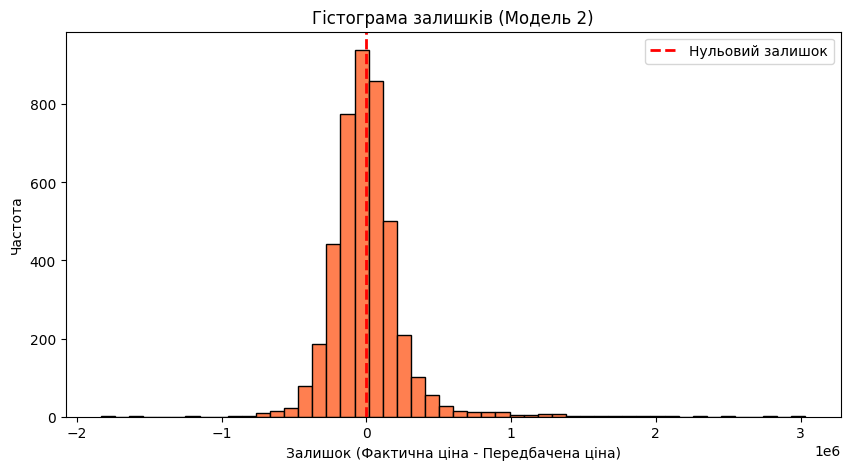

Середнє значення залишку: 1611.51


In [12]:
# Бонус — аналіз залишків
# ВАШ КОД ТУТ
# Беремо Модель 2, оскільки вона показала кращий результат (менший RMSE)
residuals = y_test - y_pred2

# Побудова гістограми
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=50, color='coral', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Нульовий залишок')
plt.title('Гістограма залишків (Модель 2)')
plt.xlabel('Залишок (Фактична ціна - Передбачена ціна)')
plt.ylabel('Частота')
plt.legend()
plt.show()

mean_residual = np.mean(residuals)
print(f"Середнє значення залишку: {mean_residual:.2f}")

**Спостереження:**

*залишки виглядають центрованими навколо нуля, оскільки найвищий стовпчик гістограми (мода) розташований саме на нульовій позначці. Це свідчить про те, що для більшості будинків модель видає прогноз, дуже близький до реальної ціни. Щодо нормальності розподілу, то він загалом нагадує дзвоноподібну криву, проте має помітний «правий хвіст». Це означає, що в даних є дорогі об'єкти, ціну яких модель систематично занижує (фактична ціна значно вища за прогнозовану).*

*Якби середнє значення залишків суттєво відхилялося від нуля (наприклад, було б зміщене далеко вправо або вліво), це вказувало б на наявність систематичної помилки (bias) у моделі. Оскільки на моєму графіку основна маса помилок зосереджена навколо нуля, можна зробити висновок, що моя модель є незміщеною і добре справляється з описом основної частини даних.*